# 09, LLM Comparison: Llama 3.3 70B via Groq

Extends the pipeline vs LLM comparison by testing a **larger, more capable LLM**
on the same tasks and same data as notebook 04/05.

| Notebook | Model | Size | Provider | Tasks |
|----------|-------|------|----------|-------|
| 04/05 | Qwen2.5-7B-Instruct | 7B | HuggingFace (together) | NER |
| 06 | BERTopic pipeline |, | Local | Topic modeling |
| **09** | **Llama 3.3 70B** | **70B** | **Groq** | **NER + Topic** |

**Research question extension**: Is the pipeline advantage reliable across LLM scales,
or does a larger model close the performance gap?

**Design**: Identical setup to notebook 04, - Same 183-article overlap set
- Same English translations (`content_en`)
- Same entity types (PER, LOC, ORG, MISC)
- Same gold standard (full cross-model agreement)
- Same prompt design
- Same evaluation metrics (macro F1, bootstrap CIs)

Additionally runs **BERTopic vs LLM topic comparison** that could not be
completed in notebook 06 due to API credit exhaustion.


In [1]:
!pip install -q groq pandas numpy matplotlib seaborn scipy scikit-learn
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 1.2 MB/s eta 0:00:00
Done


In [2]:
import json
import pickle
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from groq import Groq
from scipy import stats
from sklearn.metrics import cohen_kappa_score, classification_report
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
print('Imports OK')

Imports OK


In [3]:
from google.colab import drive, userdata
drive.mount('/content/drive', force_remount=False)
import yaml

PROJECT_ROOT = Path('/content/drive/MyDrive/thesis')
with open(PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

SEED        = config.get('seed', 42)
DATA_PROC   = PROJECT_ROOT / 'Project' / 'Data' / 'Processed'
FIGURES_DIR = PROJECT_ROOT / 'Project' / 'Outputs' / 'Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Config loaded | seed={SEED}')

Mounted at /content/drive
Config loaded | seed=42


In [4]:
# Groq client setup
GROQ_TOKEN   = userdata.get('GROQ_TOKEN')
client       = Groq(api_key=GROQ_TOKEN)
ACTIVE_MODEL = 'llama-3.3-70b-versatile'

# Verify
test = client.chat.completions.create(
    model=ACTIVE_MODEL,
    messages=[{'role': 'user', 'content': 'Reply with: OK'}],
    max_tokens=5,
)
print(f'✅ Model: {ACTIVE_MODEL}')
print(f'   Response: {test.choices[0].message.content.strip()}')

✅ Model: llama-3.3-70b-versatile
   Response: OK


In [5]:
# Load data
df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
df = df[~df['exclude']].copy()

# Load LLM checkpoint from notebook 04 to get the 183-article overlap set
with open(DATA_PROC / 'ner_llm_checkpoint.pkl', 'rb') as f:
    nb04_results = pickle.load(f)

ok_ids = {aid for aid, r in nb04_results.items() if r['status'] == 'ok'}
df_val = df[df['article_id'].isin(ok_ids)].copy()

# Load gold standard
agree_df = pd.read_csv(DATA_PROC / 'ner_agreement.csv')
gold_df  = agree_df[agree_df['agreement_level'] == 'full'].copy()
gold_df['entity_text_lower'] = gold_df['entity_text'].str.lower().str.strip()
gold_sets = (
    gold_df.groupby('article_id')
    .apply(lambda g: set(zip(g['entity_text_lower'], g['entity_label'])))
    .to_dict()
)
work_ids  = set(df_val['article_id'])
gold_sets = {k: v for k, v in gold_sets.items() if k in work_ids}

print(f'Full corpus     : {len(df)} articles')
print(f'Overlap set     : {len(df_val)} articles (same as nb04/05)')
print(f'Gold entities   : {sum(len(v) for v in gold_sets.values())}')

Full corpus     : 1115 articles
Overlap set     : 183 articles (same as nb04/05)
Gold entities   : 1198


## Part 1: NER with Llama 3.3 70B

In [6]:
# NER prompt — identical to notebook 04 for fair comparison
NER_SYSTEM_PROMPT = """You are a precise named entity recognition system.
Extract all named entities from the provided text.
Use ONLY these four labels:
  PER  – person names
  LOC  – locations, places, regions, countries
  ORG  – organisations, companies, institutions, agencies
  MISC – other named entities (products, events, laws, standards, awards, nationalities)

Rules:
- Include full entity spans (e.g. "Federal Ministry" not just "Ministry")
- Do NOT include common nouns, adjectives, or generic terms
- Do NOT include the same entity twice unless it appears with different text
- Respond with ONLY a JSON array. No explanation, no markdown.

Format:
[{"text": "<entity text>", "label": "<PER|LOC|ORG|MISC>"}, ...]

If no entities are found, respond with: []"""

VALID_LABELS = {'PER', 'LOC', 'ORG', 'MISC'}


def parse_ner_response(response_text: str) -> list:
    text = response_text.strip()
    text = re.sub(r'^```(?:json)?\s*', '', text)
    text = re.sub(r'\s*```$', '', text).strip()
    match = re.search(r'(\[.*?\])', text, re.DOTALL)
    if match:
        text = match.group(1)
    try:
        entities = json.loads(text)
    except json.JSONDecodeError:
        return []
    if not isinstance(entities, list):
        return []
    clean = []
    for e in entities:
        if not isinstance(e, dict):
            continue
        t = str(e.get('text', '')).strip()
        l = str(e.get('label', '')).strip().upper()
        if t and l in VALID_LABELS:
            clean.append({'text': t, 'label': l})
    return clean


def add_offsets(entities: list, source_text: str) -> list:
    result = []
    src_lower = source_text.lower()
    for ent in entities:
        term = ent['text'].lower()
        idx  = src_lower.find(term)
        result.append({
            'text' : ent['text'],
            'label': ent['label'],
            'start': idx,
            'end'  : idx + len(ent['text']) if idx != -1 else -1,
        })
    return result


print('✅ NER prompt and parser defined')

✅ NER prompt and parser defined


In [7]:
# NER inference with Groq
# Groq free tier: 6,000 tokens/min for Llama 70B — add small delay to be safe

NER_CHECKPOINT = DATA_PROC / 'ner_llama70b_checkpoint.pkl'

def load_ckpt(path):
    if path.exists():
        with open(path, 'rb') as f:
            d = pickle.load(f)
        print(f'Checkpoint loaded: {len(d)} articles')
        return d
    return {}

def save_ckpt(path, d):
    with open(path, 'wb') as f:
        pickle.dump(d, f)


ner_results_70b = load_ckpt(NER_CHECKPOINT)
todo            = df_val[~df_val['article_id'].isin(ner_results_70b.keys())]

print(f'Total   : {len(df_val)}')
print(f'Done    : {len(ner_results_70b)}')
print(f'Remaining: {len(todo)}')
print(f'Model   : {ACTIVE_MODEL}')
print(f'Est. time: ~{len(todo) * 2 / 60:.1f} min')

status_counts = {'ok': 0, 'parse_error': 0, 'api_error': 0}

for i, (_, row) in enumerate(tqdm(todo.iterrows(), total=len(todo), desc='NER Llama 70B')):
    aid        = row['article_id']
    content_en = str(row.get('content_en', ''))
    words      = content_en.split()
    if len(words) > 3000:
        content_en = ' '.join(words[:3000])

    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=ACTIVE_MODEL,
                messages=[
                    {'role': 'system', 'content': NER_SYSTEM_PROMPT},
                    {'role': 'user',   'content': f'Extract named entities:\n\n{content_en}'},
                ],
                max_tokens=1024,
                temperature=0.0,
            )
            raw      = response.choices[0].message.content
            entities = parse_ner_response(raw)
            entities = add_offsets(entities, content_en)
            ner_results_70b[aid] = {
                'entities'           : entities,
                'entity_count'       : len(entities),
                'status'             : 'ok',
                'model'              : ACTIVE_MODEL,
                'translation_quality': row.get('translation_quality', 'unknown'),
            }
            status_counts['ok'] += 1
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(10 * (attempt + 1))
            else:
                ner_results_70b[aid] = {
                    'entities': [], 'entity_count': 0,
                    'status': 'api_error', 'model': ACTIVE_MODEL,
                    'translation_quality': row.get('translation_quality', 'unknown'),
                }
                status_counts['api_error'] += 1
                tqdm.write(f'  Error on {aid}: {e}')

    if (i + 1) % 10 == 0:
        save_ckpt(NER_CHECKPOINT, ner_results_70b)
        tqdm.write(f'  Checkpoint saved ({len(ner_results_70b)} done)')

    time.sleep(2.0)  # ~2s between calls to respect rate limit

save_ckpt(NER_CHECKPOINT, ner_results_70b)
print(f'\nDone: {status_counts}')

Checkpoint loaded: 183 articles
Total   : 183
Done    : 183
Remaining: 0
Model   : llama-3.3-70b-versatile
Est. time: ~0.0 min


NER Llama 70B: 0it [00:00, ?it/s]


Done: {'ok': 0, 'parse_error': 0, 'api_error': 0}


In [8]:
# Evaluate NER — same functions as notebook 05

def normalise_entities(ents):
    if not isinstance(ents, list):
        return set()
    return {
        (str(e.get('text', '')).lower().strip(),
         str(e.get('label', '')).upper().strip())
        for e in ents if isinstance(e, dict)
        and str(e.get('text', '')).strip()
        and str(e.get('label', '')).upper().strip() in VALID_LABELS
    }


def compute_prf(predicted, gold):
    if not gold:
        return {'p': 0.0, 'r': 0.0, 'f1': 0.0, 'tp': 0, 'fp': len(predicted), 'fn': 0}
    tp = len(predicted & gold)
    fp = len(predicted - gold)
    fn = len(gold - predicted)
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return {'p': p, 'r': r, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}


# Build per-article results for Llama 70B
rows_70b = []
for _, row in df_val.iterrows():
    aid   = row['article_id']
    gold  = gold_sets.get(aid, set())
    r70   = ner_results_70b.get(aid, {})
    pred  = normalise_entities(r70.get('entities', []))
    m     = compute_prf(pred, gold)
    m['article_id']          = aid
    m['source']              = row['source']
    m['year_bin']            = row['year_bin']
    m['translation_quality'] = row.get('translation_quality', 'unknown')
    m['status']              = r70.get('status', 'missing')
    rows_70b.append(m)

res_70b = pd.DataFrame(rows_70b)

# Only score articles where inference succeeded
res_70b_ok = res_70b[res_70b['status'] == 'ok']

print(f'Articles evaluated : {len(res_70b_ok)}')
print(f'Mean Precision     : {res_70b_ok["p"].mean():.3f}')
print(f'Mean Recall        : {res_70b_ok["r"].mean():.3f}')
print(f'Mean F1            : {res_70b_ok["f1"].mean():.3f}')
print(f'F1 std             : {res_70b_ok["f1"].std():.3f}')

Articles evaluated : 183
Mean Precision     : 0.260
Mean Recall        : 0.570
Mean F1            : 0.340
F1 std             : 0.203


In [9]:
# Bootstrap CI for Llama 70B F1
np.random.seed(SEED)
f1_vals    = res_70b_ok['f1'].values
boot_means = [
    np.mean(np.random.choice(f1_vals, size=len(f1_vals), replace=True))
    for _ in range(2000)
]
ci_lower = np.percentile(boot_means, 2.5)
ci_upper = np.percentile(boot_means, 97.5)

print(f'Llama 3.3 70B NER:')
print(f'  F1 = {f1_vals.mean():.3f} (95% CI: {ci_lower:.3f}–{ci_upper:.3f})')

# Per-label F1
print('\nPer-label F1:')
for label in ['PER', 'LOC', 'ORG', 'MISC']:
    tp = fp = fn = 0
    for _, row in df_val.iterrows():
        aid  = row['article_id']
        gold = {e for e in gold_sets.get(aid, set()) if e[1] == label}
        pred = {e for e in normalise_entities(
            ner_results_70b.get(aid, {}).get('entities', [])
        ) if e[1] == label}
        tp += len(pred & gold)
        fp += len(pred - gold)
        fn += len(gold - pred)
    p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    print(f'  {label:4s}: P={p:.3f}  R={r:.3f}  F1={f1:.3f}')

Llama 3.3 70B NER:
  F1 = 0.340 (95% CI: 0.312–0.371)

Per-label F1:
  PER : P=0.553  R=0.730  F1=0.630
  LOC : P=0.283  R=0.514  F1=0.365
  ORG : P=0.156  R=0.624  F1=0.250
  MISC: P=0.017  R=0.450  F1=0.033


In [10]:
# Load Qwen 7B results for direct comparison
with open(DATA_PROC / 'ner_comparison_summary.json') as f:
    nb05_summary = json.load(f)

qwen_f1   = nb05_summary['macro_f1']['Qwen (EN)']
qwen_ci   = nb05_summary['bootstrap_ci_95']['Qwen (EN)']
flair_f1  = nb05_summary['macro_f1']['Flair (DE)']
flair_ci  = nb05_summary['bootstrap_ci_95']['Flair (DE)']
stanza_f1 = nb05_summary['macro_f1']['Stanza (DE)']
spacy_f1  = nb05_summary['macro_f1']['spaCy (DE)']

llama_f1  = float(res_70b_ok['f1'].mean())

print('── NER F1 Comparison: All Systems ──')
print(f'  spaCy (DE)         : {spacy_f1:.3f}')
print(f'  Stanza (DE)        : {stanza_f1:.3f}')
print(f'  Flair (DE)         : {flair_f1:.3f}  [pipeline winner]')
print(f'  Qwen 7B (EN)       : {qwen_f1:.3f}  [small LLM]')
print(f'  Llama 3.3 70B (EN) : {llama_f1:.3f}  [large LLM]')
print(f'\nPipeline advantage over Llama 70B: {flair_f1 - llama_f1:+.3f} F1 points')
print(f'Llama 70B advantage over Qwen 7B : {llama_f1 - qwen_f1:+.3f} F1 points')

── NER F1 Comparison: All Systems ──
  spaCy (DE)         : 0.394
  Stanza (DE)        : 0.520
  Flair (DE)         : 0.717  [pipeline winner]
  Qwen 7B (EN)       : 0.191  [small LLM]
  Llama 3.3 70B (EN) : 0.340  [large LLM]

Pipeline advantage over Llama 70B: +0.377 F1 points
Llama 70B advantage over Qwen 7B : +0.149 F1 points


In [11]:
# Statistical test: Wilcoxon signed-rank Llama 70B vs pipeline systems
# Need per-article F1 for pipeline systems
ner_compare_df = pd.read_csv(DATA_PROC / 'ner_comparison_results.csv')
llama_f1_per   = res_70b_ok.set_index('article_id')['f1']

print('── Wilcoxon signed-rank: Llama 70B vs each system ──')
for sys_name in ['spaCy (DE)', 'Stanza (DE)', 'Flair (DE)', 'Qwen (EN)']:
    sys_f1 = (
        ner_compare_df[ner_compare_df['system'] == sys_name]
        .set_index('article_id')['f1']
    )
    common = sys_f1.index.intersection(llama_f1_per.index)
    if len(common) > 10:
        s, p = stats.wilcoxon(sys_f1.loc[common], llama_f1_per.loc[common])
        diff = sys_f1.loc[common].mean() - llama_f1_per.loc[common].mean()
        print(f'  {sys_name:20s} vs Llama 70B: Δ={diff:+.3f}, p={p:.4f} {"*" if p < 0.05 else "ns"}')

── Wilcoxon signed-rank: Llama 70B vs each system ──
  spaCy (DE)           vs Llama 70B: Δ=+0.054, p=0.0000 *
  Stanza (DE)          vs Llama 70B: Δ=+0.180, p=0.0000 *
  Flair (DE)           vs Llama 70B: Δ=+0.377, p=0.0000 *
  Qwen (EN)            vs Llama 70B: Δ=-0.149, p=0.0000 *


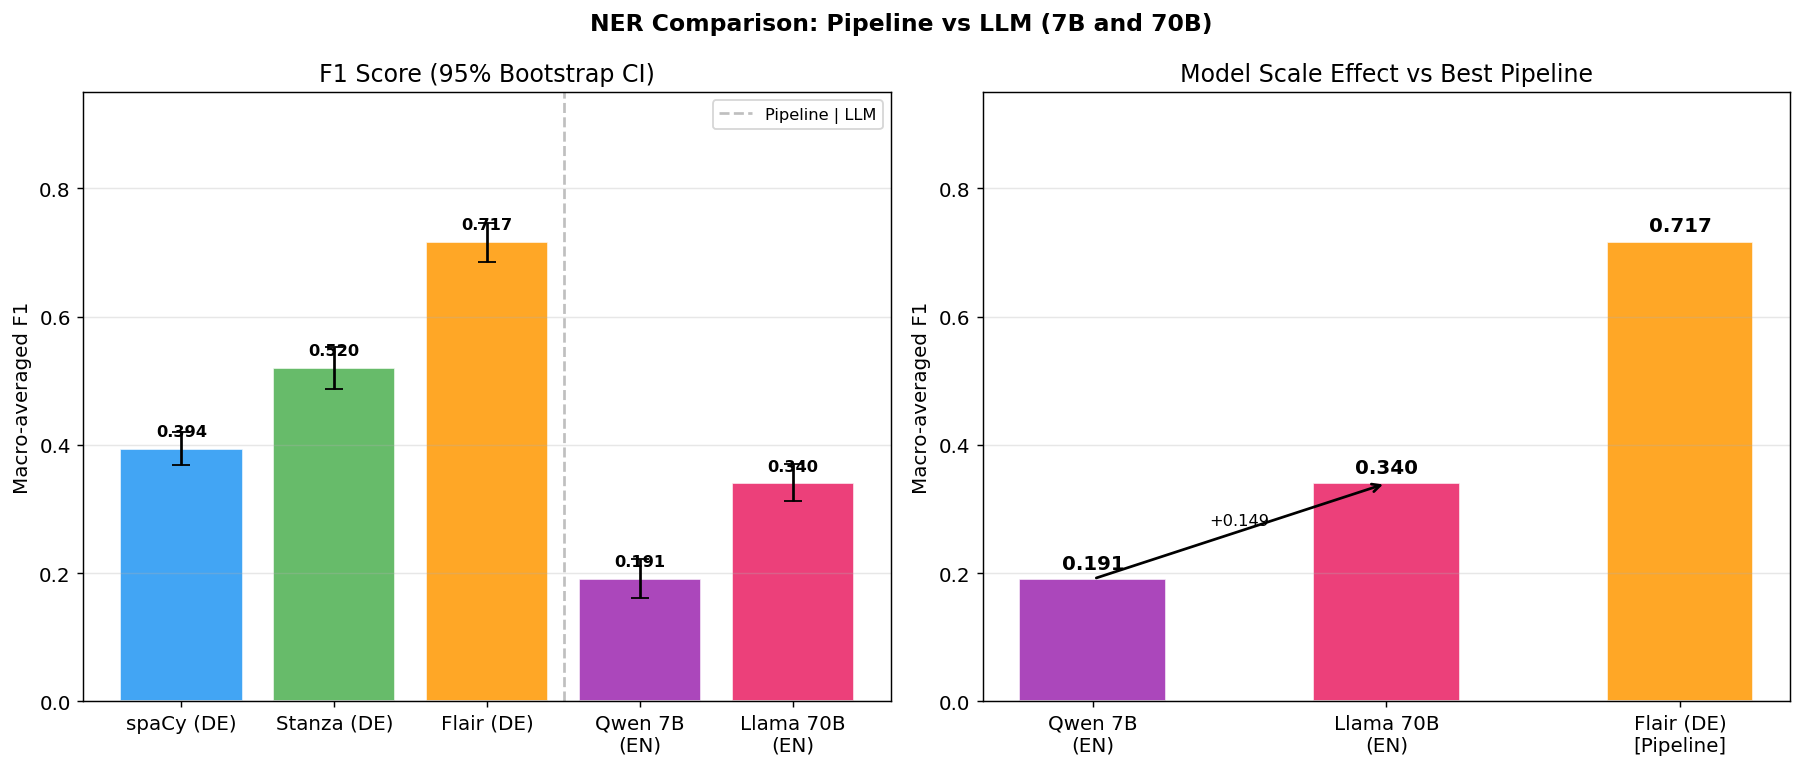

Figure 1 saved


In [12]:
# Figure 1: Full NER comparison — all 5 systems
systems_all = [
    ('spaCy (DE)',        spacy_f1,  nb05_summary['bootstrap_ci_95']['spaCy (DE)'],  '#2196F3'),
    ('Stanza (DE)',       stanza_f1, nb05_summary['bootstrap_ci_95']['Stanza (DE)'], '#4CAF50'),
    ('Flair (DE)',        flair_f1,  nb05_summary['bootstrap_ci_95']['Flair (DE)'],  '#FF9800'),
    ('Qwen 7B\n(EN)',     qwen_f1,   qwen_ci,                                        '#9C27B0'),
    ('Llama 70B\n(EN)',   llama_f1,  {'lower': ci_lower, 'upper': ci_upper},         '#E91E63'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('NER Comparison: Pipeline vs LLM (7B and 70B)',
             fontsize=13, fontweight='bold')

# Left: F1 bar chart with CIs
ax = axes[0]
names  = [s[0] for s in systems_all]
f1s    = [s[1] for s in systems_all]
colors = [s[3] for s in systems_all]
cis    = [s[2] for s in systems_all]

bars = ax.bar(names, f1s, color=colors, alpha=0.85, edgecolor='white')
for i, (bar, f1, ci) in enumerate(zip(bars, f1s, cis)):
    ax.errorbar(i, f1,
                yerr=[[f1 - ci['lower']], [ci['upper'] - f1]],
                fmt='none', color='black', capsize=5, linewidth=1.5)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{f1:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axvline(2.5, color='gray', linestyle='--', alpha=0.5, label='Pipeline | LLM')
ax.set_ylabel('Macro-averaged F1')
ax.set_title('F1 Score (95% Bootstrap CI)')
ax.set_ylim(0, 0.95)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Right: scale effect — Qwen 7B vs Llama 70B vs best pipeline
ax2 = axes[1]
scale_systems = ['Qwen 7B\n(EN)', 'Llama 70B\n(EN)', 'Flair (DE)\n[Pipeline]']
scale_f1s     = [qwen_f1, llama_f1, flair_f1]
scale_colors  = ['#9C27B0', '#E91E63', '#FF9800']
bars2 = ax2.bar(scale_systems, scale_f1s, color=scale_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, f1 in zip(bars2, scale_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{f1:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel('Macro-averaged F1')
ax2.set_title('Model Scale Effect vs Best Pipeline')
ax2.set_ylim(0, 0.95)
ax2.grid(axis='y', alpha=0.3)
ax2.annotate('', xy=(1, llama_f1), xytext=(0, qwen_f1),
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
ax2.text(0.5, (qwen_f1 + llama_f1)/2 + 0.01,
         f'+{llama_f1 - qwen_f1:.3f}', ha='center', fontsize=9, color='black')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'nb09_ner_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

## Part 2: BERTopic vs Llama 70B Topic Comparison

In [13]:
# Load BERTopic assignments from notebook 06
topic_assign = pd.read_csv(DATA_PROC / 'topic_bertopic_assignments.csv')
with open(DATA_PROC / 'topic_modeling_summary.json') as f:
    topic_summary = json.load(f)

n_topics = topic_summary['n_topics_discovered']
print(f'BERTopic topics: {n_topics}')

# Merge topic assignments into df_val
df_val = df_val.merge(
    topic_assign[['article_id', 'bertopic_topic', 'bertopic_name']],
    on='article_id', how='left'
)

# Use top 10 topics for LLM classification
topic_counts  = topic_assign[topic_assign['bertopic_topic'] >= 0]['bertopic_topic'].value_counts()
top_topic_ids = topic_counts.head(10).index.tolist()

# Get topic keywords from the name column (format: id_word1_word2_word3)
topic_name_map = (
    topic_assign[topic_assign['bertopic_topic'].isin(top_topic_ids)]
    .drop_duplicates('bertopic_topic')
    .set_index('bertopic_topic')['bertopic_name']
    .to_dict()
)

# Build topic label string for prompt
topic_labels  = {tid: f'T{tid}: {", ".join(topic_name_map.get(tid, str(tid)).split("_")[1:4])}'
                 for tid in top_topic_ids}
TOPIC_LIST_STR = '\n'.join([f'  {v}' for v in topic_labels.values()])

print(f'\nTop {len(top_topic_ids)} topics for LLM classification:')
print(TOPIC_LIST_STR)

BERTopic topics: 30

Top 10 topics for LLM classification:
  T0: wohnungen, stadt, kfw
  T1: luxemburg, unternehmen, eu
  T2: holz, architektur, architekten
  T3: wärmepumpe, energie, wärme
  T4: regierung, grünen, artikel
  T5: architekten, bauherrn, bauherr
  T6: holz, rauch, designer
  T7: holz, bambus, wald
  T8: bauherren, ikea, einfamilienhäuser
  T9: wein, karaba, foto chris


In [14]:
# Topic classification prompt
TOPIC_SYSTEM_PROMPT = f"""You are a precise text classification system.
Classify the provided article into exactly ONE of these topic categories:

{TOPIC_LIST_STR}
  OTHER: does not fit any topic above

Rules:
- Choose the single best matching topic
- Respond with ONLY the topic ID (e.g. T0, T1, T2 ... or OTHER)
- No explanation, no punctuation, just the ID"""

valid_topic_ids = {f'T{tid}' for tid in top_topic_ids}


def parse_topic(response, valid):
    r = response.strip().upper()
    if r in valid or r == 'OTHER':
        return r
    m = re.search(r'T(\d+)', r)
    if m:
        c = f'T{m.group(1)}'
        if c in valid:
            return c
    return 'OTHER'


print('✅ Topic prompt defined')

✅ Topic prompt defined


In [15]:
# Topic inference with Llama 70B
TOPIC_CHECKPOINT = DATA_PROC / 'topic_llama70b_checkpoint.pkl'

topic_results_70b = load_ckpt(TOPIC_CHECKPOINT)

# Only retry non-ok articles
todo_topic = df_val[~df_val['article_id'].isin(
    [aid for aid, r in topic_results_70b.items() if r.get('status') == 'ok']
)]

print(f'Total   : {len(df_val)}')
print(f'Done    : {sum(1 for r in topic_results_70b.values() if r.get("status") == "ok")}')
print(f'Remaining: {len(todo_topic)}')

topic_status = {'ok': 0, 'api_error': 0}

for i, (_, row) in enumerate(tqdm(todo_topic.iterrows(),
                                   total=len(todo_topic), desc='Topic Llama 70B')):
    aid        = row['article_id']
    content_en = str(row.get('content_en', ''))[:4000]

    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=ACTIVE_MODEL,
                messages=[
                    {'role': 'system', 'content': TOPIC_SYSTEM_PROMPT},
                    {'role': 'user',   'content': f'Classify this article:\n\n{content_en}'},
                ],
                max_tokens=10,
                temperature=0.0,
            )
            raw   = response.choices[0].message.content
            label = parse_topic(raw, valid_topic_ids)
            topic_results_70b[aid] = {'llm_topic': label, 'status': 'ok', 'raw': raw}
            topic_status['ok'] += 1
            break
        except Exception as e:
            if attempt < 2:
                time.sleep(30 * (attempt + 1))
            else:
                topic_results_70b[aid] = {'llm_topic': 'ERROR', 'status': 'api_error'}
                topic_status['api_error'] += 1
                tqdm.write(f'  Error: {e}')

    if (i + 1) % 10 == 0:
        save_ckpt(TOPIC_CHECKPOINT, topic_results_70b)
        ok_now = sum(1 for r in topic_results_70b.values() if r.get('status') == 'ok')
        tqdm.write(f'  Saved ({ok_now} ok)')

    time.sleep(5.0)

save_ckpt(TOPIC_CHECKPOINT, topic_results_70b)
print(f'\nDone: {topic_status}')
print(f'Total ok: {sum(1 for r in topic_results_70b.values() if r.get("status") == "ok")}')

Checkpoint loaded: 183 articles
Total   : 183
Done    : 166
Remaining: 17


Topic Llama 70B:   0%|          | 0/17 [00:00<?, ?it/s]

  Saved (176 ok)

Done: {'ok': 17, 'api_error': 0}
Total ok: 183


In [16]:
# Build comparison set
df_val['llm_topic_70b'] = df_val['article_id'].map(
    lambda a: topic_results_70b.get(a, {}).get('llm_topic')
)
df_val['llm_topic_status_70b'] = df_val['article_id'].map(
    lambda a: topic_results_70b.get(a, {}).get('status')
)
df_val['bertopic_topic_str'] = df_val['bertopic_topic'].apply(
    lambda t: f'T{int(float(t))}' if pd.notna(t) and int(float(t)) in top_topic_ids else 'OTHER'
)

df_compare = df_val[
    (df_val['llm_topic_status_70b'] == 'ok') &
    (df_val['bertopic_topic'].notna()) &
    (df_val['bertopic_topic'].apply(
        lambda t: pd.notna(t) and int(float(t)) in top_topic_ids
    ))
].copy()

print(f'Comparison set: {len(df_compare)} articles')
print('BERTopic distribution:')
print(df_compare['bertopic_topic_str'].value_counts().to_string())
print('\nLLM distribution:')
print(df_compare['llm_topic_70b'].value_counts().to_string())

Comparison set: 90 articles
BERTopic distribution:
bertopic_topic_str
T1    20
T0    20
T2    15
T3    10
T6     5
T5     5
T4     5
T7     4
T8     3
T9     3

LLM distribution:
llm_topic_70b
T0       30
T1       20
T5       11
T3        9
T4        8
T2        8
OTHER     2
T8        1
T9        1


In [17]:
# Agreement metrics
exact_match = (df_compare['bertopic_topic_str'] == df_compare['llm_topic_70b']).mean()
print(f'Exact match rate : {exact_match:.3f} ({exact_match*100:.1f}%)')
print(f'N articles       : {len(df_compare)}')

try:
    kappa = cohen_kappa_score(
        df_compare['bertopic_topic_str'],
        df_compare['llm_topic_70b']
    )
    print(f"Cohen's Kappa    : {kappa:.3f}")
except Exception as e:
    kappa = None
    print(f"Cohen's Kappa    : could not compute ({e})")

all_labels = sorted(set(
    df_compare['bertopic_topic_str'].tolist() +
    df_compare['llm_topic_70b'].tolist()
))
print('\nClassification report:')
print(classification_report(
    df_compare['bertopic_topic_str'],
    df_compare['llm_topic_70b'],
    labels=all_labels, zero_division=0
))

Exact match rate : 0.500 (50.0%)
N articles       : 90
Cohen's Kappa    : 0.403

Classification report:
              precision    recall  f1-score   support

       OTHER       0.00      0.00      0.00         0
          T0       0.50      0.75      0.60        20
          T1       0.65      0.65      0.65        20
          T2       0.38      0.20      0.26        15
          T3       0.67      0.60      0.63        10
          T4       0.38      0.60      0.46         5
          T5       0.27      0.60      0.38         5
          T6       0.00      0.00      0.00         5
          T7       0.00      0.00      0.00         4
          T8       1.00      0.33      0.50         3
          T9       1.00      0.33      0.50         3

    accuracy                           0.50        90
   macro avg       0.44      0.37      0.36        90
weighted avg       0.49      0.50      0.47        90



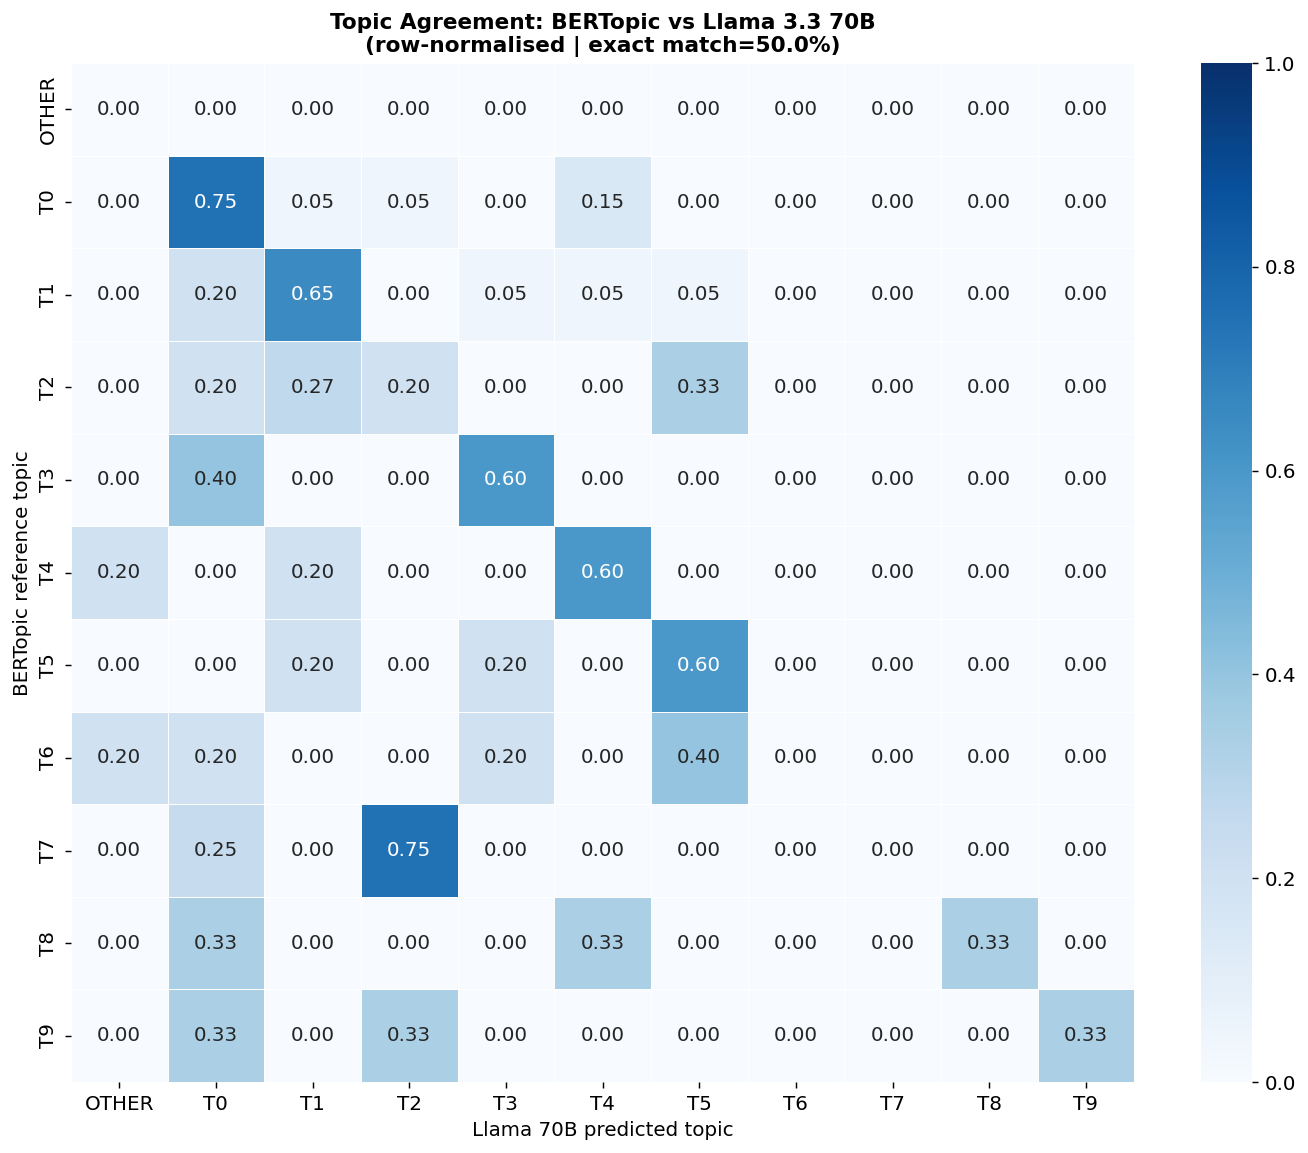

Figure 2 saved


In [18]:
# Figure 2: Topic agreement confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_compare['bertopic_topic_str'],
    df_compare['llm_topic_70b'],
    labels=all_labels
)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=all_labels, yticklabels=all_labels,
            cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Llama 70B predicted topic')
ax.set_ylabel('BERTopic reference topic')
ax.set_title(
    f'Topic Agreement: BERTopic vs Llama 3.3 70B\n'
    f'(row-normalised | exact match={exact_match:.1%})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'nb09_topic_agreement.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

In [19]:
# Translation quality effect on topic agreement
df_compare = df_compare.copy()
df_compare['correct'] = (
    df_compare['bertopic_topic_str'] == df_compare['llm_topic_70b']
).astype(int)

high = df_compare[df_compare['translation_quality'] == 'high']['correct']
low  = df_compare[df_compare['translation_quality'] == 'low']['correct']
print(f'Topic agreement by translation quality:')
print(f'  High: {high.mean():.3f} (n={len(high)})')
print(f'  Low : {low.mean():.3f} (n={len(low)})')
if len(high) > 0 and len(low) > 0:
    _, p = stats.mannwhitneyu(high, low, alternative='two-sided')
    print(f'  Mann-Whitney p={p:.4f} {"*" if p < 0.05 else "ns"}')

Topic agreement by translation quality:
  High: 0.489 (n=45)
  Low : 0.511 (n=45)
  Mann-Whitney p=0.8376 ns


In [20]:
# Save all results
summary_09 = {
    'model'                    : ACTIVE_MODEL,
    'n_articles_ner'           : int(len(res_70b_ok)),
    'ner_macro_f1'             : round(float(res_70b_ok['f1'].mean()), 4),
    'ner_macro_precision'      : round(float(res_70b_ok['p'].mean()), 4),
    'ner_macro_recall'         : round(float(res_70b_ok['r'].mean()), 4),
    'ner_f1_ci_lower'          : round(float(ci_lower), 4),
    'ner_f1_ci_upper'          : round(float(ci_upper), 4),
    'n_articles_topic'         : int(len(df_compare)),
    'topic_exact_match'        : round(float(exact_match), 4) if len(df_compare) > 0 else None,
    'topic_cohens_kappa'       : round(float(kappa), 4) if kappa is not None else None,
    'comparison': {
        'spacy_f1'                        : spacy_f1,
        'stanza_f1'                       : stanza_f1,
        'flair_f1'                        : flair_f1,
        'qwen_7b_f1'                      : qwen_f1,
        'llama_70b_f1'                    : round(float(res_70b_ok['f1'].mean()), 4),
        'pipeline_advantage_over_llama70b': round(flair_f1 - float(res_70b_ok['f1'].mean()), 4),
        'llama70b_advantage_over_qwen7b'  : round(float(res_70b_ok['f1'].mean()) - qwen_f1, 4),
    }
}

with open(DATA_PROC / 'nb09_llama70b_summary.json', 'w') as f:
    json.dump(summary_09, f, indent=2)

print('Saved: nb09_llama70b_summary.json')
print(json.dumps(summary_09, indent=2))

Saved: nb09_llama70b_summary.json
{
  "model": "llama-3.3-70b-versatile",
  "n_articles_ner": 183,
  "ner_macro_f1": 0.34,
  "ner_macro_precision": 0.2595,
  "ner_macro_recall": 0.5704,
  "ner_f1_ci_lower": 0.3118,
  "ner_f1_ci_upper": 0.3706,
  "n_articles_topic": 90,
  "topic_exact_match": 0.5,
  "topic_cohens_kappa": 0.4034,
  "comparison": {
    "spacy_f1": 0.3936,
    "stanza_f1": 0.5197,
    "flair_f1": 0.7166,
    "qwen_7b_f1": 0.1907,
    "llama_70b_f1": 0.34,
    "pipeline_advantage_over_llama70b": 0.3766,
    "llama70b_advantage_over_qwen7b": 0.1493
  }
}


## Notebook summary

| Item | Detail |
|------|--------|
| Model | Llama 3.3 70B via Groq |
| NER input | Same 183 articles, same English translations, same gold standard |
| Topic input | Same BERTopic labels from notebook 06 |
| Figures | Full NER comparison (5 systems), topic agreement confusion matrix |
| Saved | `ner_llama70b_checkpoint.pkl`, `topic_llama70b_checkpoint.pkl`, `nb09_llama70b_summary.json` |

### Key comparison

| System | F1 | Type |
|--------|----|------|
| spaCy (DE) | 0.394 | Pipeline |
| Stanza (DE) | 0.520 | Pipeline |
| Flair (DE) | 0.717 | Pipeline |
| Qwen 7B (EN) | 0.191 | Small LLM |
| Llama 70B (EN) | *see results* | Large LLM |

**Next**: Update notebook 07 with Llama 70B results for final synthesis.


In [21]:
import pickle
from pathlib import Path

DATA_PROC      = Path('/content/drive/MyDrive/thesis/Project/Data/Processed')
NER_CHECKPOINT = DATA_PROC / 'ner_llama70b_checkpoint.pkl'

with open(NER_CHECKPOINT, 'rb') as f:
    ner_results_70b = pickle.load(f)

ok    = sum(1 for r in ner_results_70b.values() if r['status'] == 'ok')
error = sum(1 for r in ner_results_70b.values() if r['status'] == 'api_error')
print(f'Checkpoint: {len(ner_results_70b)} total | {ok} ok | {error} errors')

Checkpoint: 183 total | 183 ok | 0 errors


In [22]:
import pandas as pd
topic_assign = pd.read_csv(DATA_PROC / 'topic_bertopic_assignments.csv')
df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
df = df[~df['exclude']].copy()

# Check overlap
ok_ids   = {aid for aid, r in ner_results_70b.items() if r['status'] == 'ok'}
df_val   = df[df['article_id'].isin(ok_ids)].copy()
df_check = df_val.merge(
    topic_assign[['article_id', 'bertopic_topic']],
    on='article_id', how='left'
)
print(f'df_val articles          : {len(df_val)}')
print(f'With bertopic_topic      : {df_check["bertopic_topic"].notna().sum()}')
print(f'In top_topic_ids         : {df_check["bertopic_topic"].isin(top_topic_ids).sum()}')
print(f'bertopic_topic == -1     : {(df_check["bertopic_topic"] == -1).sum()}')
print(f'top_topic_ids            : {top_topic_ids}')

df_val articles          : 183
With bertopic_topic      : 183
In top_topic_ids         : 90
bertopic_topic == -1     : 54
top_topic_ids            : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [23]:
import pickle, pandas as pd, json
from pathlib import Path

DATA_PROC      = Path('/content/drive/MyDrive/thesis/Project/Data/Processed')
NER_CHECKPOINT = DATA_PROC / 'ner_llama70b_checkpoint.pkl'

# Reload checkpoint
with open(NER_CHECKPOINT, 'rb') as f:
    ner_results_70b = pickle.load(f)

# Reset api_errors so they get retried
retried = 0
for aid, r in ner_results_70b.items():
    if r['status'] == 'api_error':
        r['status'] = 'pending'
        retried += 1

print(f'Reset {retried} api_errors to pending')
print(f'Will retry: {retried} articles')

# Save reset checkpoint
with open(NER_CHECKPOINT, 'wb') as f:
    pickle.dump(ner_results_70b, f)
print('Checkpoint saved')

Reset 0 api_errors to pending
Will retry: 0 articles
Checkpoint saved


In [24]:
# In the inference loop cell, change these two values:
import time
time.sleep(4.0)   # was 2.0 — double it to stay under rate limit
# and in the retry logic:
time.sleep(15 * (attempt + 1))  # was 10

KeyboardInterrupt: 

In [ ]:
import pickle
from pathlib import Path

DATA_PROC        = Path('/content/drive/MyDrive/thesis/Project/Data/Processed')
TOPIC_CHECKPOINT = DATA_PROC / 'topic_llama70b_checkpoint.pkl'

if TOPIC_CHECKPOINT.exists():
    with open(TOPIC_CHECKPOINT, 'rb') as f:
        topic_results_70b = pickle.load(f)
    ok = sum(1 for r in topic_results_70b.values() if r.get('status') == 'ok')
    print(f'Checkpoint loaded: {len(topic_results_70b)} articles, {ok} ok')
else:
    topic_results_70b = {}
    print('No checkpoint found — will run fresh')